In [1]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Nạp module src
sys.path.append(os.path.abspath('..'))
from src.models.models import RetailReturnModeler

# Khởi tạo class
modeler = RetailReturnModeler()

# Load và chia data
X_train, X_test, y_train, y_test = modeler.load_and_split_data()
print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")
print(f"Tỷ lệ nhãn is_return trong Train:\n{y_train.value_counts(normalize=True)}")

Kích thước tập Train: (3496, 3)
Kích thước tập Test: (875, 3)
Tỷ lệ nhãn is_return trong Train:
is_return
0    0.636442
1    0.363558
Name: proportion, dtype: float64


In [2]:
# Huấn luyện Supervised (có SMOTE)
modeler.train_supervised_models(X_train, y_train)

# Huấn luyện Semi-supervised (giữ 20% nhãn)
modeler.train_semi_supervised(X_train, y_train, labeled_ratio=0.2)

Đang áp dụng SMOTE...
Đã huấn luyện xong các mô hình Supervised!
Bắt đầu thực nghiệm Semi-supervised với 20.0% nhãn...
Đã huấn luyện xong mô hình Semi-supervised!


,"estimator estimator: estimator objectAn estimator object implementing `fit` and `predict_proba`.Invoking the `fit` method will fit a clone of the passed estimator,which will be stored in the `estimator_` attribute... versionadded:: 1.6 `estimator` was added to replace `base_estimator`.",RandomForestC...ndom_state=42)
,"threshold threshold: float, default=0.75The decision threshold for use with `criterion='threshold'`.Should be in [0, 1). When using the `'threshold'` criterion, a:ref:`well calibrated classifier ` should be used.",0.8
,"criterion criterion: {'threshold', 'k_best'}, default='threshold'The selection criterion used to select which labels to add to thetraining set. If `'threshold'`, pseudo-labels with predictionprobabilities above `threshold` are added to the dataset. If `'k_best'`,the `k_best` pseudo-labels with highest prediction probabilities areadded to the dataset. When using the 'threshold' criterion, a:ref:`well calibrated classifier ` should be used.",'threshold'
,"k_best k_best: int, default=10The amount of samples to add in each iteration. Only used when`criterion='k_best'`.",10
,"max_iter max_iter: int or None, default=10Maximum number of iterations allowed. Should be greater than or equalto 0. If it is `None`, the classifier will continue to predict labelsuntil no new pseudo-labels are added, or all unlabeled samples havebeen labeled.",10
,"verbose verbose: bool, default=FalseEnable verbose output.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1



--- Báo cáo phân lớp: Logistic_Regression ---
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       557
           1       0.74      0.71      0.72       318

    accuracy                           0.80       875
   macro avg       0.79      0.78      0.78       875
weighted avg       0.80      0.80      0.80       875


--- Báo cáo phân lớp: Random_Forest ---
              precision    recall  f1-score   support

           0       0.89      0.73      0.80       557
           1       0.64      0.84      0.73       318

    accuracy                           0.77       875
   macro avg       0.77      0.79      0.77       875
weighted avg       0.80      0.77      0.78       875


--- Báo cáo phân lớp: XGBoost ---
              precision    recall  f1-score   support

           0       0.87      0.74      0.80       557
           1       0.64      0.81      0.71       318

    accuracy                           0.76       875
   ma

,Model,F1_Score,ROC_AUC
3,Semi_Supervised_SelfTraining,0.727848,0.868517
1,Random_Forest,0.727520,0.874140
0,Logistic_Regression,0.723200,0.872210
2,XGBoost,0.711111,0.860173


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17452\1906660197.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1_Score', y='Model', data=results_df, palette='viridis')


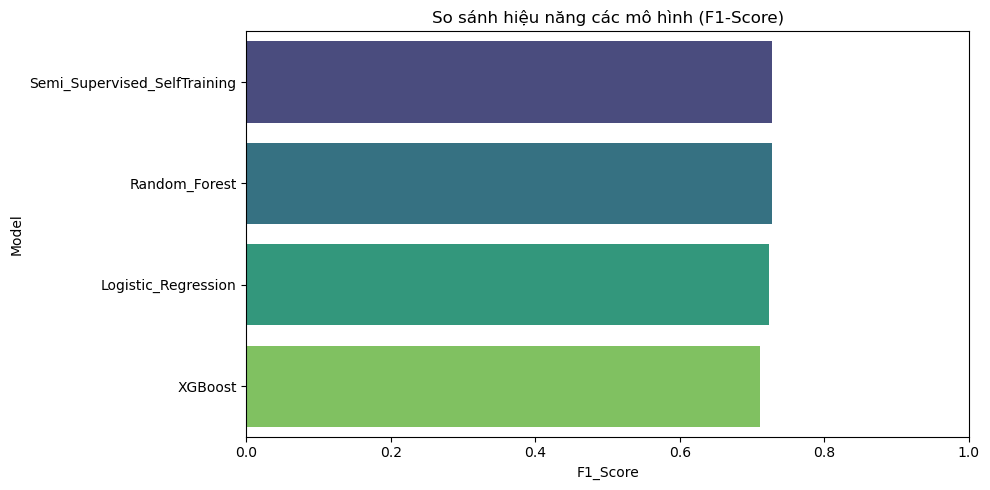

In [4]:
import os

# Xem bảng kết quả tổng sắp
results_df = modeler.evaluate_models(X_test, y_test)
display(results_df)

# Vẽ biểu đồ so sánh F1-Score
plt.figure(figsize=(10, 5))
sns.barplot(x='F1_Score', y='Model', data=results_df, palette='viridis')
plt.title('So sánh hiệu năng các mô hình (F1-Score)')
plt.xlim(0, 1)
plt.tight_layout()

# --- PHẦN CODE ĐƯỢC THÊM VÀO ĐỂ SỬA LỖI ---
# Định nghĩa đường dẫn thư mục muốn lưu
save_dir = '../artifacts/figures'

# Tự động tạo thư mục nếu chưa có (exist_ok=True giúp bỏ qua nếu thư mục đã tồn tại)
os.makedirs(save_dir, exist_ok=True)
# ------------------------------------------

# Lưu ảnh vào đường dẫn (đã đảm bảo thư mục tồn tại)
plt.savefig(f'{save_dir}/model_comparison.png')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17452\4176650031.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='magma')


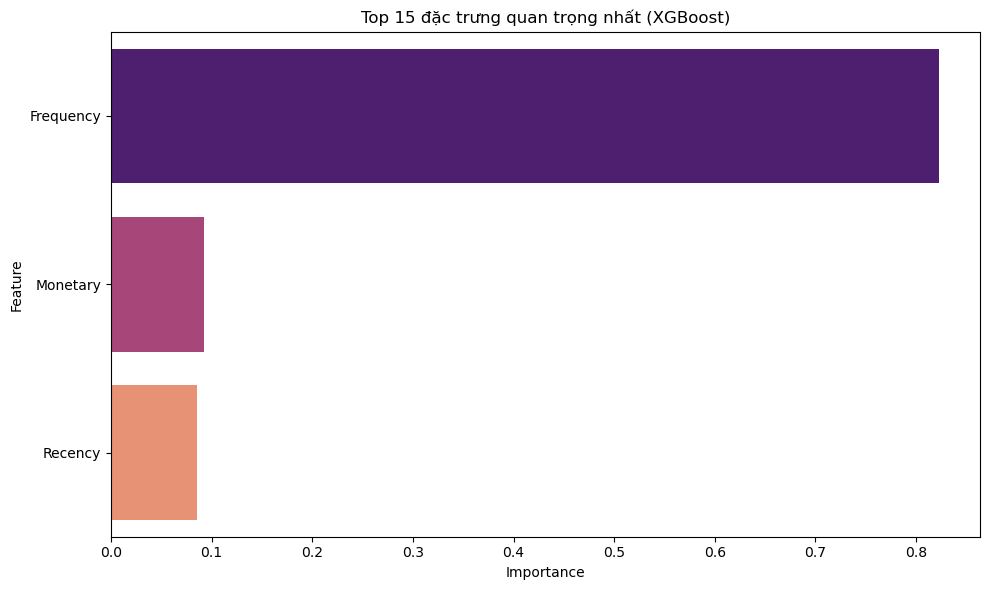

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy mô hình tốt nhất (thường là XGBoost) để xem yếu tố nào làm khách hàng trả hàng
best_model = modeler.models['XGBoost']
importances = best_model.feature_importances_

# Khởi tạo DataFrame với pandas (đã fix lỗi NameError 'pd')
feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='magma')
plt.title('Top 15 đặc trưng quan trọng nhất (XGBoost)')
plt.tight_layout()

# Tự động tạo thư mục nếu chưa có để tránh lỗi FileNotFoundError
save_dir = '../artifacts/figures'
os.makedirs(save_dir, exist_ok=True)

# Lưu ảnh và hiển thị
plt.savefig(f'{save_dir}/feature_importance_xgb.png')
plt.show()

In [7]:
import joblib
import os

# 1. Tạo thư mục chứa model nếu chưa có
model_dir = '../artifacts/models'
os.makedirs(model_dir, exist_ok=True)

# 2. Lưu mô hình XGBoost tốt nhất
model_path = f'{model_dir}/xgboost_best_model.pkl'
joblib.dump(best_model, model_path)

print(f"✅ Đã lưu mô hình thành công tại: {model_path}")

✅ Đã lưu mô hình thành công tại: ../artifacts/models/xgboost_best_model.pkl
